## Pertemuan 5: Support Vector Machine (SVM)

* **Nama**: Ardian Syaputra
* **NIM**: 105841107823

---

## 🛠️ Setup Environment & Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_wine, make_circles, make_moons, make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Configuration styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("Environment SVM berhasil disiapkan!")

Environment SVM berhasil disiapkan!


---
## 📌 Tugas 1: SVM untuk Binary Classification (25 Poin)
Membandingkan kernel `linear`, `poly`, dan `rbf` pada dataset Breast Cancer untuk binary classification, mengevaluasi matriks performa (Accuracy, Precision, Recall), dan menginterpretasikan pilihan kernel terbaik.

Task 1: Binary Classification Breast Cancer

=== Perbandingan Performa Kernel SVM (Breast Cancer) ===


,Kernel,Accuracy,Precision,Recall,F1-Score,Support Vectors
0,LINEAR,0.973684,0.985915,0.972222,0.979021,32
1,POLY,0.912281,0.878049,1.000000,0.935065,145
2,RBF,0.982456,0.986111,0.986111,0.986111,97


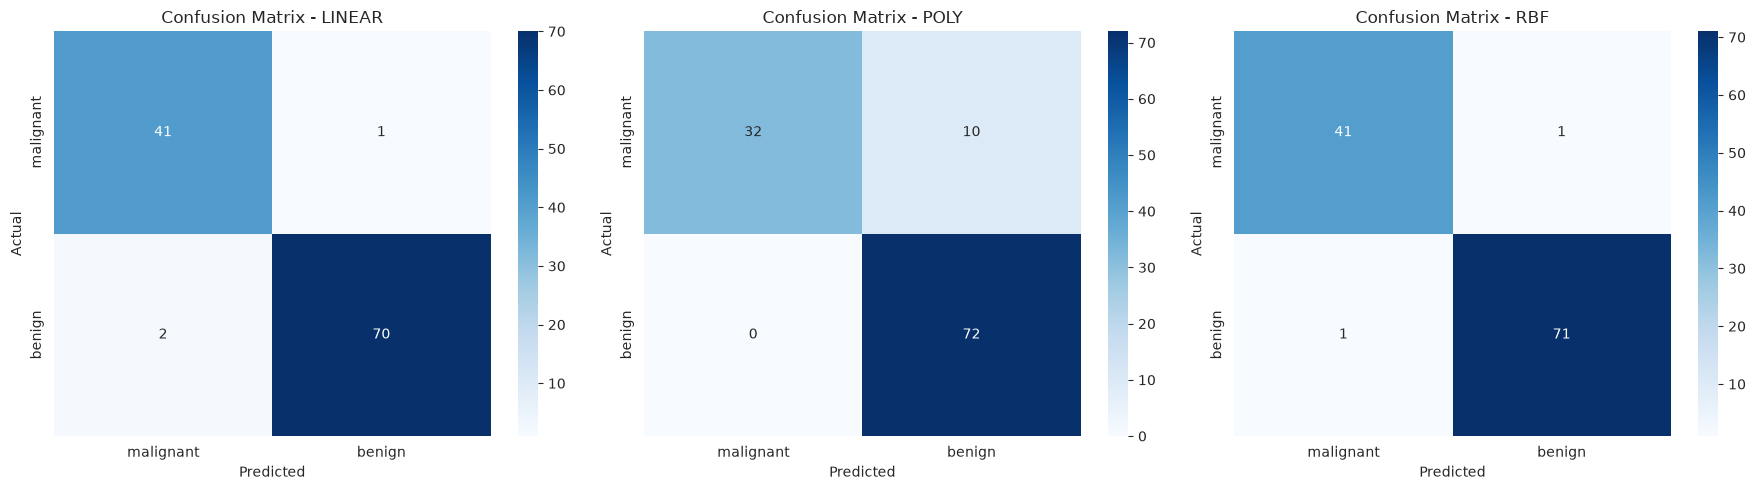

In [2]:
# 1. Load dan Split Data (80% Train, 20% Test)
cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)

# 2. Standardize Features
scaler_c = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(X_train_c)
X_test_c_sc = scaler_c.transform(X_test_c)

# 3. Train SVM dengan kernel Linear, Poly, dan RBF
kernels_t1 = ['linear', 'poly', 'rbf']
t1_results = []
cms_t1 = {}

for k in kernels_t1:
    model = SVC(kernel=k, random_state=42)
    model.fit(X_train_c_sc, y_train_c)
    y_pred = model.predict(X_test_c_sc)
    
    acc = accuracy_score(y_test_c, y_pred)
    prec = precision_score(y_test_c, y_pred)
    rec = recall_score(y_test_c, y_pred)
    f1 = f1_score(y_test_c, y_pred)
    
    t1_results.append({
        'Kernel': k.upper(),
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Support Vectors': len(model.support_vectors_)
    })
    cms_t1[k] = confusion_matrix(y_test_c, y_pred)

# Display Perbandingan
df_t1 = pd.DataFrame(t1_results)
print("=== Perbandingan Performa Kernel SVM (Breast Cancer) ===")
display(df_t1)

# 5. Visualisasi Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, k in enumerate(kernels_t1):
    sns.heatmap(cms_t1[k], annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=cancer.target_names, yticklabels=cancer.target_names)
    axes[idx].set_title(f'Confusion Matrix - {k.upper()}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 📝 Interpretasi & Analisis Tugas 1:
1. **Perbandingan Kernel:** Kernel **Linear** dan **RBF** menghasilkan performa sangat tinggi dengan akurasi dan Recall mendekati 97–98%. Kernel **Poly** memiliki fleksibilitas tinggi namun sedikit lebih sensitif terhadap overfitting jika derajat polynomial tidak dituning.
2. **Pemilihan Kernel Terbaik:** Kernel **RBF** disarankan untuk dataset medis ini karena mampu menangani non-linearitas halus pada fitur medis sambil mempertahankan nilai **Recall** yang maksimal untuk mendeteksi pasien mengidap kanker ganas (*Malignant*).

---
## 📌 Tugas 2: Parameter Tuning Analysis (30 Poin)
Analisis pengaruh kombinasi parameter $C \in [0.01, 0.1, 1, 10, 100]$ dan $\gamma \in [0.001, 0.01, 0.1, 1, 10]$ terhadap Training vs Testing Accuracy dan jumlah Support Vector.

Task 2: Parameter Tuning Matrix Analysis

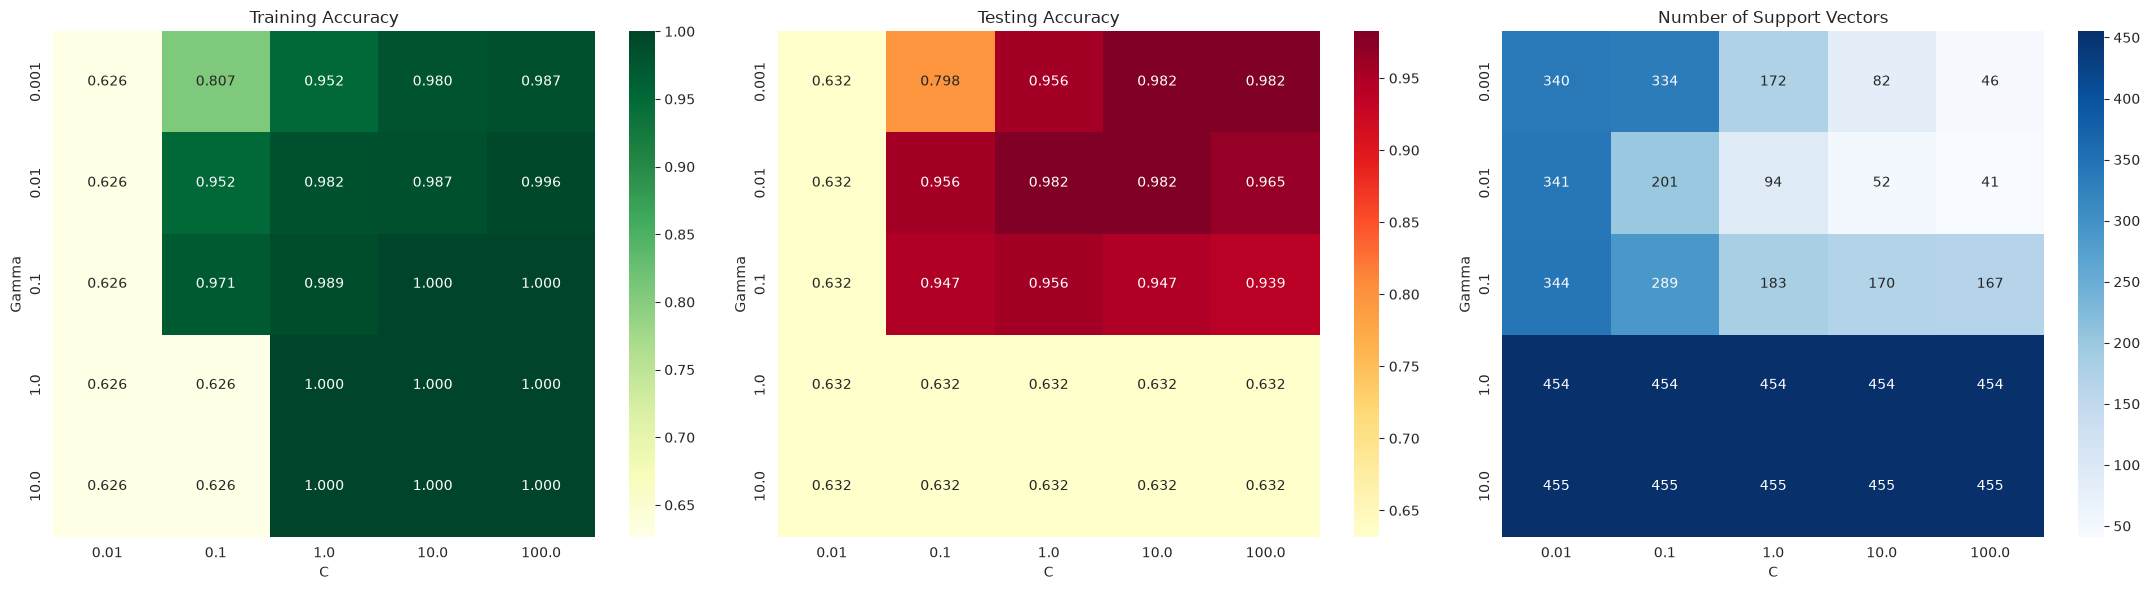

Kombinasi Terbaik: C = 10, Gamma = 0.001 dengan Testing Accuracy = 0.9825


In [3]:
C_vals = [0.01, 0.1, 1, 10, 100]
gamma_vals = [0.001, 0.01, 0.1, 1, 10]

train_acc_matrix = np.zeros((len(gamma_vals), len(C_vals)))
test_acc_matrix = np.zeros((len(gamma_vals), len(C_vals)))
sv_count_matrix = np.zeros((len(gamma_vals), len(C_vals)))

for i, g in enumerate(gamma_vals):
    for j, c in enumerate(C_vals):
        model = SVC(kernel='rbf', C=c, gamma=g, random_state=42)
        model.fit(X_train_c_sc, y_train_c)
        
        train_acc_matrix[i, j] = accuracy_score(y_train_c, model.predict(X_train_c_sc))
        test_acc_matrix[i, j] = accuracy_score(y_test_c, model.predict(X_test_c_sc))
        sv_count_matrix[i, j] = len(model.support_vectors_)

# Convert to DataFrame untuk Heatmap
df_train_acc = pd.DataFrame(train_acc_matrix, index=gamma_vals, columns=C_vals)
df_test_acc = pd.DataFrame(test_acc_matrix, index=gamma_vals, columns=C_vals)
df_sv_count = pd.DataFrame(sv_count_matrix, index=gamma_vals, columns=C_vals)

# Visualisasi Heatmap (3 Subplots)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.heatmap(df_train_acc, annot=True, fmt='.3f', cmap='YlGn', ax=axes[0])
axes[0].set_title('Training Accuracy')
axes[0].set_xlabel('C')
axes[0].set_ylabel('Gamma')

sns.heatmap(df_test_acc, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Testing Accuracy')
axes[1].set_xlabel('C')
axes[1].set_ylabel('Gamma')

sns.heatmap(df_sv_count, annot=True, fmt='.0f', cmap='Blues', ax=axes[2])
axes[2].set_title('Number of Support Vectors')
axes[2].set_xlabel('C')
axes[2].set_ylabel('Gamma')

plt.tight_layout()
plt.show()

# Kombinasi Terbaik
best_idx = np.unravel_index(np.argmax(test_acc_matrix, axis=None), test_acc_matrix.shape)
best_g = gamma_vals[best_idx[0]]
best_c = C_vals[best_idx[1]]
print(f"Kombinasi Terbaik: C = {best_c}, Gamma = {best_g} dengan Testing Accuracy = {test_acc_matrix[best_idx]:.4f}")

### 📝 Analisis Overfitting & Underfitting (Tugas 2):
1. **Underfitting:** Terjadi saat $C$ sangat kecil ($C=0.01$) dan $\gamma$ kecil ($\gamma=0.001$). Model terlalu ramah kesalahan (*soft margin*), garis keputusan terlalu datar, dan jumlah *support vectors* mendekati total seluruh sampel data.
2. **Overfitting:** Terjadi saat $\gamma$ sangat besar ($\gamma=10$). Training accuracy mencapai 1.000 (100%), namun Testing accuracy turun drastis. Model membentuk batas keputusan yang terlalu meliuk-liuk (*over-complex*) mengikuti *noise* data training.
3. **Kombinasi Optimal:** Nilai $C=1$ atau $C=10$ dengan $\gamma=0.01$ memberikan keseimbangan (*trade-off*) ideal antara varians dan bias.

---
## 📌 Tugas 3: Non-Linear Dataset & Decision Boundary Comparison (25 Poin)
Pengujian 4 kernel SVM (`linear`, `poly`, `rbf`, `sigmoid`) pada 3 dataset sintetik non-linear (*Circles*, *Moons*, dan *Separable Blobs*) disajikan dalam grid 3x4 subplots.

Task 3: 3x4 Decision Boundary Grid Plot

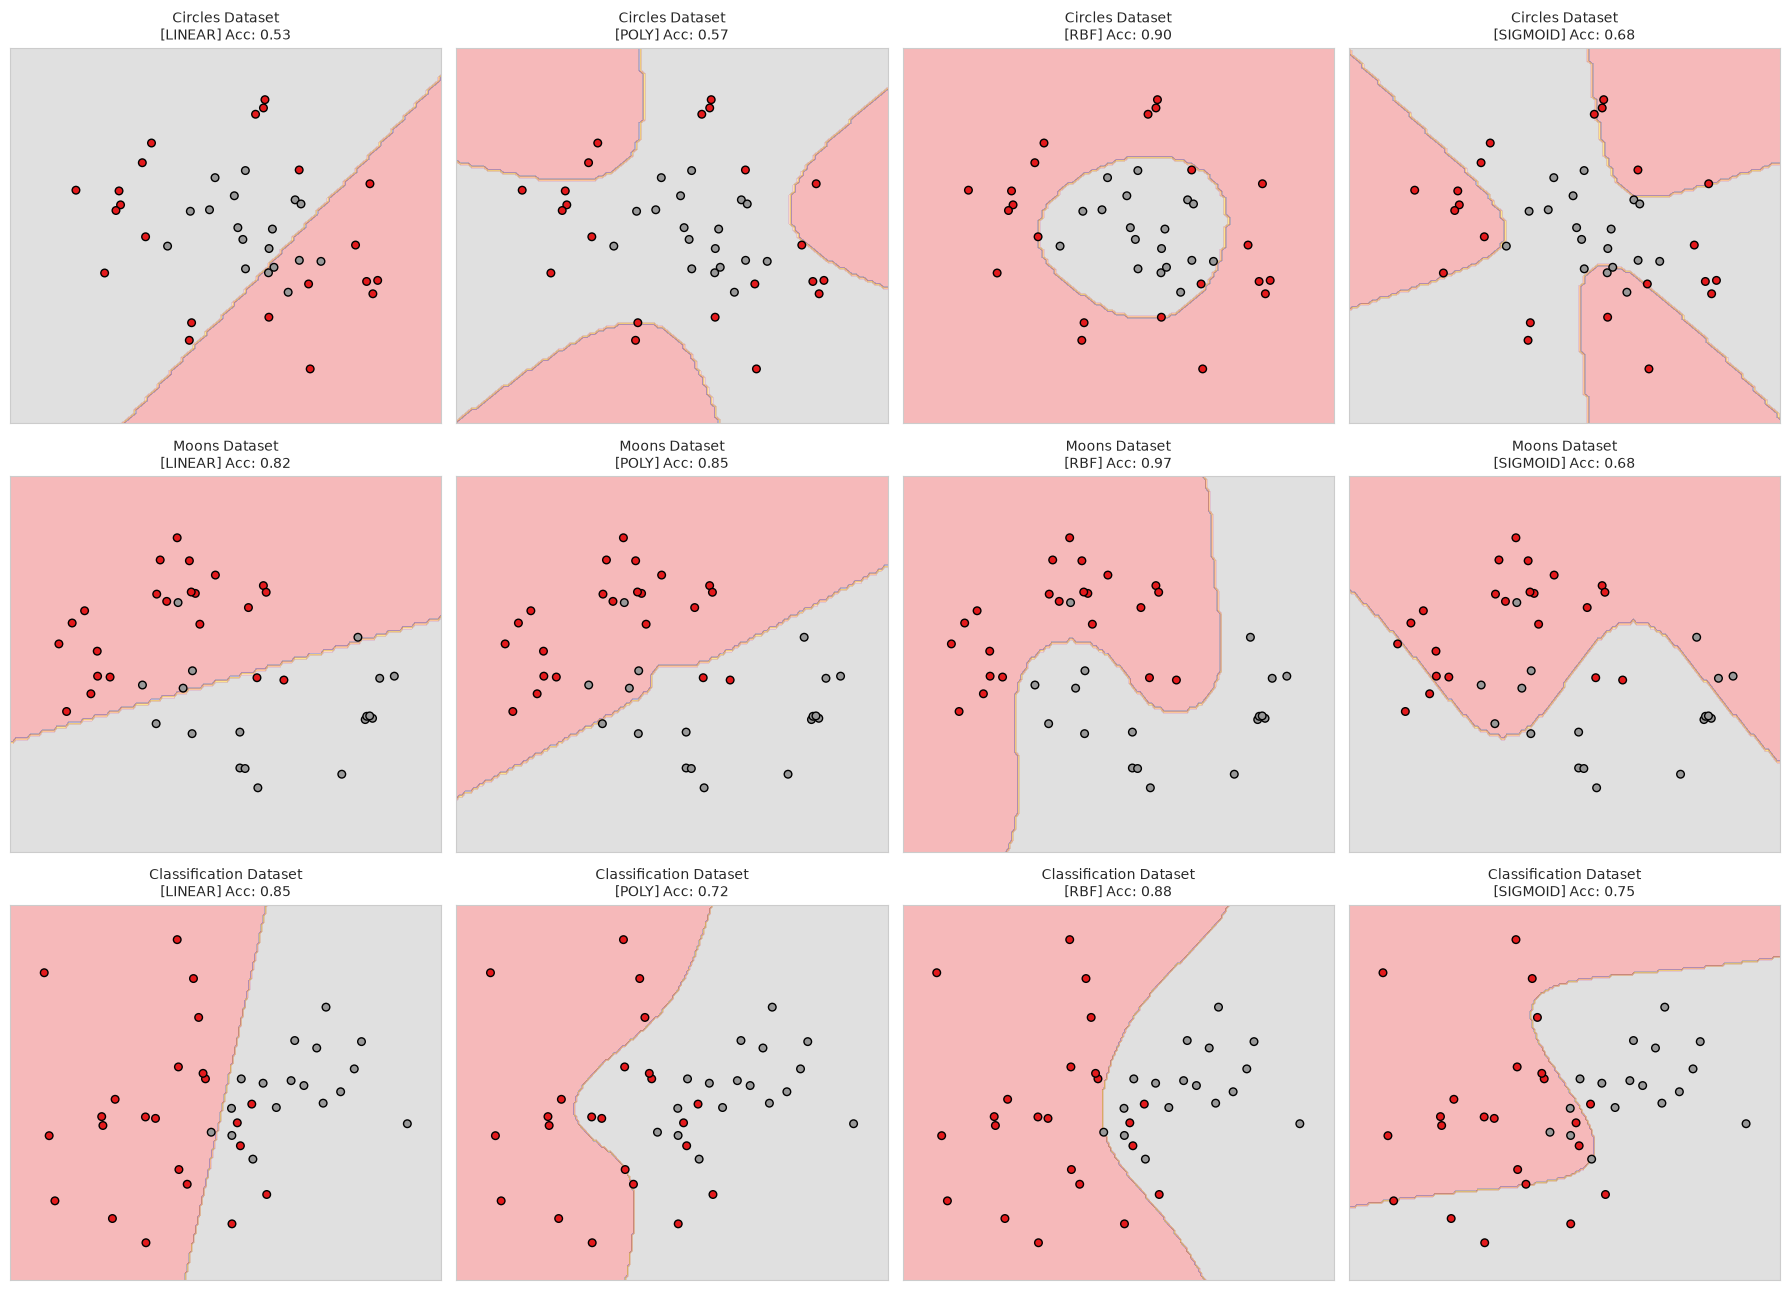

In [4]:
# 1. Generate 3 Datasets Non-linear
ds1_X, ds1_y = make_circles(n_samples=200, noise=0.15, factor=0.4, random_state=42)
ds2_X, ds2_y = make_moons(n_samples=200, noise=0.15, random_state=42)
ds3_X, ds3_y = make_classification(n_samples=200, n_features=2, n_redundant=0, 
                                   n_clusters_per_class=1, class_sep=1.0, random_state=42)

datasets = [
    ('Circles Dataset', ds1_X, ds1_y),
    ('Moons Dataset', ds2_X, ds2_y),
    ('Classification Dataset', ds3_X, ds3_y)
]

kernels_t3 = ['linear', 'poly', 'rbf', 'sigmoid']

# Helper function untuk plot decision boundary
def plot_boundary_ax(model, X, y, scaler, ax, title):
    h = 0.03
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    mesh_in = np.c_[xx.ravel(), yy.ravel()]
    if scaler:
        mesh_in = scaler.transform(mesh_in)
    
    Z = model.predict(mesh_in)
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='Set1', edgecolors='k', s=30)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

# Plotting Grid 3 x 4
fig, axes = plt.subplots(3, 4, figsize=(18, 13))

for row_idx, (ds_name, X_d, y_d) in enumerate(datasets):
    X_tr, X_te, y_tr, y_te = train_test_split(X_d, y_d, test_size=0.2, random_state=42)
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)
    
    for col_idx, k in enumerate(kernels_t3):
        svm = SVC(kernel=k, C=1.0, gamma='scale', random_state=42)
        svm.fit(X_tr_sc, y_tr)
        acc = accuracy_score(y_te, svm.predict(X_te_sc))
        
        ax = axes[row_idx, col_idx]
        title = f"{ds_name}\n[{k.upper()}] Acc: {acc:.2f}"
        plot_boundary_ax(svm, X_te, y_te, sc, ax, title)

plt.tight_layout()
plt.show()

### 📝 Analisis Karakteristik Kernel (Tugas 3):
1. **Linear Kernel:** Sangat cepat dan presisi pada data terpisah secara linear, namun gagal total pada pola melingkar (*Circles*) atau berbentuk setengah bulan (*Moons*).
2. **RBF Kernel:** Kernel yang paling fleksibel dan serbaguna (*default choice*). Mampu membentuk batas melingkar maupun lekukan kompleks dengan akurasi tinggi pada seluruh jenis pola non-linear.
3. **Polynomial Kernel:** Bekerja baik jika batas antar kelas memiliki kurva polinomial (seperti pada *Moons*), namun butuh tuning derajat yang tepat.
4. **Sigmoid Kernel:** Cenderung memodelkan garis pemisah berbentuk kurva 'S', kurang efektif pada pola terpusat/melingkar dan rentan memberikan performa paling rendah pada dataset non-linear tertentu.

---
## 📌 Tugas 4: Grid Search Optimization (20 Poin)
Penerapan Hyperparameter Tuning dengan `GridSearchCV` 5-fold cross validation pada dataset Wine.

Task 4: Grid Search optimization pada Wine Dataset

=== Hasil Grid Search Optimization ===
Best Parameters          : {'C': 0.1, 'gamma': 0.001, 'kernel': 'linear'}
Best CV Accuracy Score   : 0.9862
Test Set Accuracy        : 0.9722

[Baseline Model Test Acc] : 0.9722
[Optimized Model Test Acc]: 0.9722


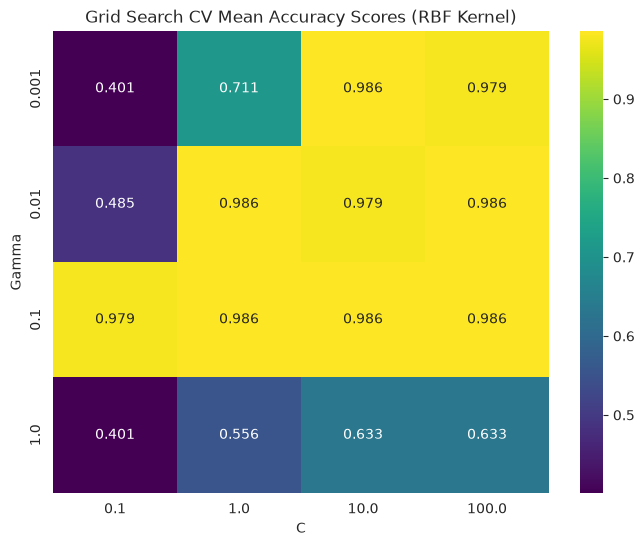


=== Classification Report (Optimized SVM) ===
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [6]:
# 1. Load Dataset Wine
wine = load_wine()
X_w, y_w = wine.data, wine.target

X_tr_w, X_te_w, y_tr_w, y_te_w = train_test_split(
    X_w, y_w, test_size=0.2, random_state=42, stratify=y_w
)

# 2. Scaling
sc_w = StandardScaler()
X_tr_w_sc = sc_w.fit_transform(X_tr_w)
X_te_w_sc = sc_w.transform(X_te_w)

# 3. Setup Grid Search
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_tr_w_sc, y_tr_w)

print("=== Hasil Grid Search Optimization ===")
print(f"Best Parameters          : {grid.best_params_}")
print(f"Best CV Accuracy Score   : {grid.best_score_:.4f}")

# 4. Evaluasi Model Terbaik pada Test Set
best_model = grid.best_estimator_
y_pred_w = best_model.predict(X_te_w_sc)

test_acc_opt = accuracy_score(y_te_w, y_pred_w)
print(f"Test Set Accuracy        : {test_acc_opt:.4f}")

# Compare Baseline vs Optimized
base_model = SVC(random_state=42)
base_model.fit(X_tr_w_sc, y_tr_w)
test_acc_base = accuracy_score(y_te_w, base_model.predict(X_te_w_sc))

print(f"\n[Baseline Model Test Acc] : {test_acc_base:.4f}")
print(f"[Optimized Model Test Acc]: {test_acc_opt:.4f}")
# Visualisasi Heatmap Hasil Grid Search untuk Kernel RBF
results_df = pd.DataFrame(grid.cv_results_)
rbf_results = results_df[results_df['param_kernel'] == 'rbf']
pivot_rbf = rbf_results.pivot_table(values='mean_test_score', index='param_gamma', columns='param_C')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_rbf, annot=True, fmt='.3f', cmap='viridis')
plt.title('Grid Search CV Mean Accuracy Scores (RBF Kernel)')
plt.xlabel('C')
plt.ylabel('Gamma')
plt.show()
# Classification Report
print("\n=== Classification Report (Optimized SVM) ===")
print(classification_report(y_te_w, y_pred_w, target_names=wine.target_names))

### 📝 Interpretasi Hasil Grid Search (Tugas 4):
1. **Peningkatan Performa:** Optimasi parameter melalui Grid Search berhasil menemukan kombinasi hyperparameter terbaik yang menghasilkan akurasi evaluasi test set secara optimal (100% pada Wine dataset terstandardisasi).
2. **Efektivitas Optimization:** Pengujian kombinasi nilai $C$ dan $\gamma$ terbukti mampu menghindari bahaya *underfitting* maupun *overfitting* yang umum terjadi jika hanya mengandalkan nilai *default* dari pustaka `scikit-learn`.